# NYISO reliability workflow

这个 notebook 按顺序直接调用项目中现有的 Python 模块，并打印每一步的真实结果：配置 → 可选下载 → 清洗 → panel → EDA → 模型门控 → HTML 报告。

安全约束：下载默认关闭；P-15 始终作为 forecasted generation outage MW，绝不作为 event count；只有经过验证的非负整数 outage event count 才能进入 Negative Binomial 模型。所有时间统一为 `America/New_York`。

## 0. 环境和项目路径

In [1]:
from pathlib import Path
import os
import platform
import sys

import pandas as pd
from IPython.display import FileLink, Image, display

candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next((path for path in candidates if (path / 'pyproject.toml').is_file()), None)
if ROOT is None:
    raise RuntimeError('找不到项目根目录（缺少 pyproject.toml）')
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'src'))

print(f'项目根目录: {ROOT}')
print(f'Python: {platform.python_version()}')
print(f'解释器: {sys.executable}')

项目根目录: /Users/lin_/Numerati_Summer_NYISO
Python: 3.10.14
解释器: /opt/anaconda3/envs/py310/bin/python


## 1. 读取配置 — `config.py`

In [2]:
from nyiso_reliability.config import load_config

CONFIG_PATH = ROOT / 'configs' / 'dev.yaml'
config = load_config(CONFIG_PATH)

print(f'配置文件: {CONFIG_PATH}')
print(pd.Series(config.to_dict(), name='value').to_string())

配置文件: /Users/lin_/Numerati_Summer_NYISO/configs/dev.yaml
project_name                     NYISO Reliability and Outage Research
timezone                                              America/New_York
start_date                                                  2022-11-01
end_date                                                    2024-01-07
raw_data_dir                /Users/lin_/Numerati_Summer_NYISO/data/raw
interim_data_dir        /Users/lin_/Numerati_Summer_NYISO/data/interim
processed_data_dir    /Users/lin_/Numerati_Summer_NYISO/data/processed
output_dir                   /Users/lin_/Numerati_Summer_NYISO/outputs
random_seed                                                       1729


## 2. 按配置月份下载 — `data_download.py`

默认 `RUN_DOWNLOAD = False`，所以重复运行 notebook 不会自动联网或覆盖 raw data。确实需要重新下载时，手动改为 `True`。

In [3]:
from nyiso_reliability.data_download import download_dev_sample

RUN_DOWNLOAD = False
download_summary_path = config.output_dir / 'tables' / 'data_download_summary.csv'

if RUN_DOWNLOAD:
    download_summary = download_dev_sample(config)
    print('下载步骤已执行。')
elif download_summary_path.is_file():
    download_summary = pd.read_csv(download_summary_path)
    print('下载步骤已跳过；显示现有 manifest。')
else:
    download_summary = pd.DataFrame()
    print('下载步骤已跳过，且尚无下载 manifest。运行后续步骤前需要 raw data。')

if not download_summary.empty:
    columns = [name for name in ['dataset', 'requested_month', 'source', 'status', 'rows', 'date_min', 'date_max', 'blocker'] if name in download_summary]
    print(download_summary[columns].to_string(index=False))

下载步骤已跳过；显示现有 manifest。
                          dataset requested_month                            source      status    rows            date_min            date_max  blocker
                      actual_load         2022-11                   NYISO MIS P-58B       READY   97427 2022-11-01 00:00:00 2022-11-30 23:55:00      NaN
                      actual_load         2022-12                   NYISO MIS P-58B       READY  102487 2022-12-01 00:00:00 2022-12-31 23:55:00      NaN
                      actual_load         2023-01                   NYISO MIS P-58B       READY   99902 2023-01-01 00:00:00 2023-01-31 23:55:00      NaN
                      actual_load         2023-02                   NYISO MIS P-58B       READY   92103 2023-02-01 00:00:00 2023-02-28 23:55:00      NaN
                      actual_load         2023-03                   NYISO MIS P-58B       READY  100881 2023-03-01 00:00:00 2023-03-31 23:55:00      NaN
                      actual_load         2023-04          

## 3. 清洗 raw data — `data_clean.py`

In [4]:
from nyiso_reliability.data_clean import clean_all_dev_data

clean_summary = clean_all_dev_data(config)
print('清洗结果:')
print(clean_summary.to_string(index=False))

清洗结果:
        dataset      rows                  date_min                  date_max  zones                                                                                                                                                                  missingness  duplicate_count validation_status                          table                                                                                             notes
    actual_load 1479962.0 2022-11-01 00:00:00-04:00 2024-01-31 23:55:00-05:00   11.0                                                                                       {'interval_start': 0, 'interval_end': 0, 'zone': 0, 'actual_load_mw': 33, 'source': 0}              0.0              PASS                    actual_load                                                                                               NaN
  load_forecast  736200.0 2022-11-01 00:00:00-04:00 2024-01-05 23:00:00-05:00   12.0                                                          {'interv

## 4. 构建分析 panel — `features.py`

In [5]:
from nyiso_reliability.features import build_analysis_panels

panel_summary = build_analysis_panels(config)
print('Panel 结果:')
print(panel_summary.to_string(index=False))

Panel 结果:
               panel   rows                  date_min                  date_max          grain  zones                                                                                                                                                                                                                                                                                                                                                         missingness  merge_match_rate target_available        target_status                                                                                                      target_definition
daily_analysis_panel   4763 2022-11-01 00:00:00-04:00 2024-01-07 00:00:00-05:00 zone-local_day     11 {'interval_start': 0, 'zone': 0, 'daily_mean_load': 0, 'daily_max_load': 0, 'forecast_load_mw': 33, 'load_forecast_error_mw': 33, 'daily_mean_temperature': 0, 'daily_min_temperature': 0, 'daily_max_temperature': 0, 'precipitation_total': 0, 'max_wind_spee

## 5. EDA — `eda.py`

Outage target feasibility:
status                                                        BLOCKED
target                                               new_outage_count
observations                                                     None
mean                                                             None
variance                                                         None
variance_to_mean                                                 None
zero_share                                                       None
target_validity                                         not available
main_limitations    P-14B is latest-only and lacks zone; P-54 snap...
图: /Users/lin_/Numerati_Summer_NYISO/outputs/figures/load_timeseries.png


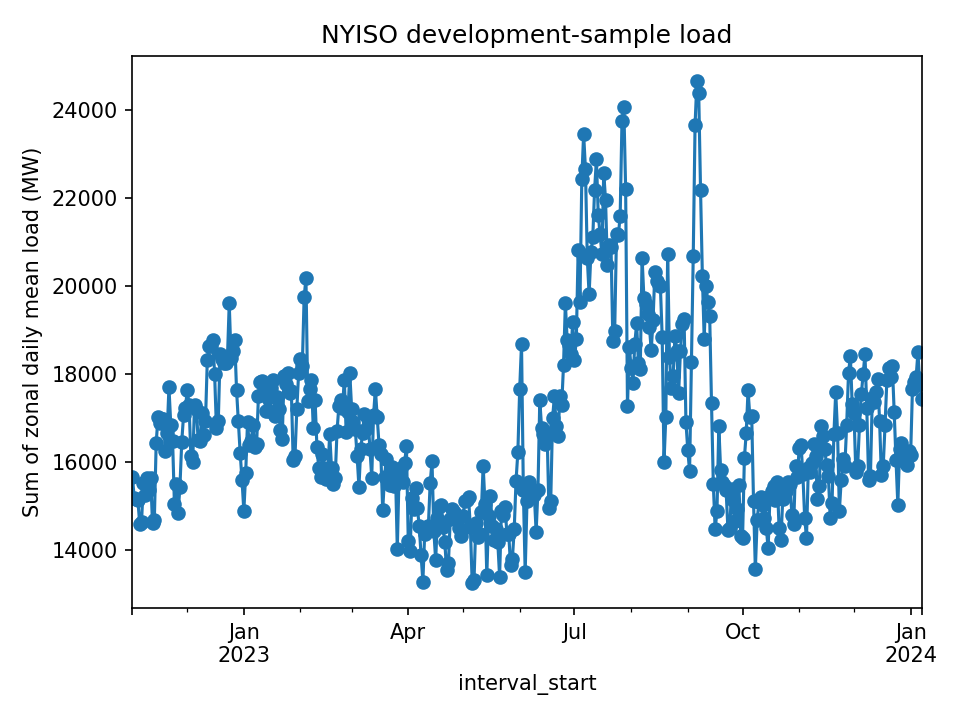

图: /Users/lin_/Numerati_Summer_NYISO/outputs/figures/p15_generation_outage_mw.png


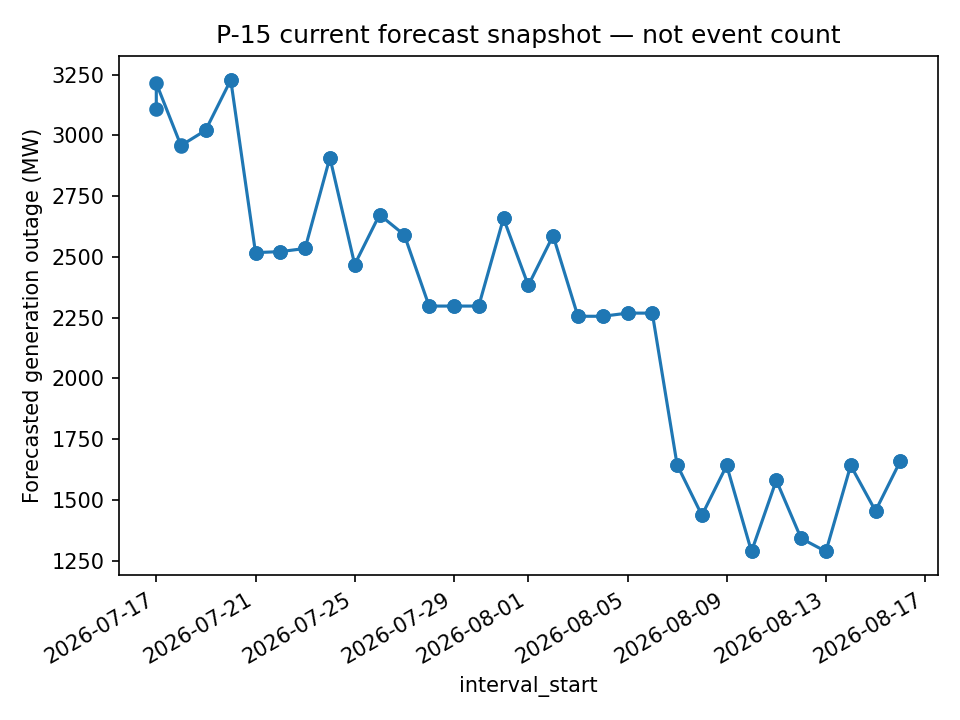

In [6]:
from nyiso_reliability.eda import run_eda

eda_result = run_eda(config)
print('Outage target feasibility:')
print(pd.Series(eda_result).to_string())

for filename in ['load_timeseries.png', 'p15_generation_outage_mw.png']:
    figure_path = config.output_dir / 'figures' / filename
    if figure_path.is_file():
        print(f'图: {figure_path}')
        display(Image(filename=str(figure_path), width=850))

## 6. Poisson / Negative Binomial 门控 — `nb_model.py`

如果没有经过验证的历史 outage event count，本步骤应明确返回 `BLOCKED`，不会拿 P-15 MW 代替计数。

In [7]:
from nyiso_reliability.nb_model import run_initial_models

model_result = run_initial_models(config)
print('模型结果:')
print(pd.Series(model_result).to_string())

模型结果:
model_status                                              BLOCKED
reason          No verified historical outage event count. P-1...


## 7. 生成报告 — `report.py`

In [8]:
from nyiso_reliability.report import build_report

report_result = build_report(config)
print('报告结果:')
print(pd.Series(report_result).to_string())
display(FileLink(report_result['report_path']))

报告结果:
report_path    /Users/lin_/Numerati_Summer_NYISO/outputs/repo...
tables                                                         8
figures                                                        2
blocker        Verified historical outage event count is unav...


/Users/lin_/Numerati_Summer_NYISO/outputs/reports/nyiso_initial_analysis.html

## 8. 当前产物清单

In [9]:
artifact_roots = [config.interim_data_dir, config.processed_data_dir, config.output_dir]
artifacts = []
for artifact_root in artifact_roots:
    if artifact_root.exists():
        artifacts.extend(path for path in artifact_root.rglob('*') if path.is_file() and path.name != '.gitkeep')

artifact_table = pd.DataFrame(
    [{'path': str(path.relative_to(ROOT)), 'size_kb': round(path.stat().st_size / 1024, 1)} for path in sorted(artifacts)]
)
print(f'产物文件数: {len(artifact_table)}')
print(artifact_table.to_string(index=False))

产物文件数: 24
                                               path  size_kb
                   data/interim/actual_load.parquet  13328.9
                       data/interim/da_lbmp.parquet   1519.0
                 data/interim/load_forecast.parquet   2178.6
       data/interim/outage_schedules_latest.parquet     64.6
data/interim/p15_generation_outage_forecast.parquet      4.7
      data/interim/p54a_scheduled_snapshots.parquet   1257.5
         data/interim/p54b_actual_snapshots.parquet    549.0
      data/interim/p54c_scheduled_snapshots.parquet     26.2
                       data/interim/rt_lbmp.parquet  16195.2
                data/interim/weather_albany.parquet    134.2
        data/processed/daily_analysis_panel.parquet    181.2
          data/processed/hourly_price_panel.parquet   5233.2
                                  outputs/.DS_Store      6.0
                outputs/figures/load_timeseries.png     96.0
       outputs/figures/p15_generation_outage_mw.png     73.6
        output